In [ ]:
# Assignment 3 – Observable ML with MLflow
## Fashion-MNIST GAN Training with Experiment Tracking

This notebook uses **`train.py`** instrumented with **MLflow** to track, compare, and version GAN experiments on Fashion-MNIST.

### Workflow
1. Install dependencies (`mlflow`, `tensorflow`, etc.)
2. Launch the MLflow tracking UI
3. Run `train.py` **5 times** with different hyperparameters
4. Analyze results from MLflow to identify the best configuration

In [ ]:
## Phase 1 — Environment Setup

In [ ]:
# Install dependencies
!pip install mlflow tensorflow keras numpy pandas matplotlib --quiet

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Verify imports
import mlflow
import tensorflow as tf
print(f"MLflow version : {mlflow.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print("\nTo launch the MLflow UI, run in a separate terminal:")
print("  mlflow ui --port 5000")
print("Then open http://localhost:5000")

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
## Phase 2 — Verify `train.py` is instrumented with MLflow

The updated `train.py` includes the following **MLflow pillars**:
- **Experiment**: `mlflow.set_experiment("Assignment3_YousefHendy")`
- **Run context**: `with mlflow.start_run(run_name=...)`
- **Parameters**: `epochs`, `batch_size`, `learning_rate`, `noise_dim`, `momentum`, `dropout`
- **Tags**: `student_id = "YousefHendy"`, `model_type`, `framework`
- **Live logging**: `d_loss`, `g_loss`, `d_accuracy` logged at every epoch with `step=epoch`
- **Model artifact**: `mlflow.keras.log_model(generator, "generator_model")`

(60000, 784)


In [ ]:
# Quick look at train.py to confirm MLflow integration
with open("train.py", "r") as f:
    content = f.read()
# Show key MLflow lines
for line in content.splitlines():
    stripped = line.strip()
    if any(kw in stripped for kw in ["mlflow.", "import mlflow", "argparse"]):
        print(line)

(60000, 28, 28, 1)


In [ ]:
## Phase 3 — Run 5 Experiments with Different Hyperparameters

Each run varies one or more hyperparameters to explore convergence, stability, and reproducibility.

| Run | LR | Batch Size | Epochs | Dropout | Notes |
|-----|------|-----------|--------|---------|-------|
| 1 | 0.0002 | 100 | 30 | 0.5 | Baseline |
| 2 | 0.001 | 100 | 30 | 0.5 | Higher LR |
| 3 | 0.0001 | 100 | 30 | 0.5 | Lower LR |
| 4 | 0.0002 | 64 | 30 | 0.5 | Smaller batch |
| 5 | 0.0002 | 100 | 30 | 0.3 | Lower dropout |

1.0 -1.0


In [ ]:
# ── Run 1: Baseline ──────────────────────────────────────────────────────────
!python train.py --epochs 30 --batch_size 100 --learning_rate 0.0002 --dropout 0.5 --run_name "Run1_baseline"

c:\Users\youhe\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\youhe\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
# ── Run 2: Higher learning rate ──────────────────────────────────────────────
!python train.py --epochs 30 --batch_size 100 --learning_rate 0.001 --dropout 0.5 --run_name "Run2_high_lr"

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,656 (1.22 MB)

 Trainable params: 318,864 (1.22 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# ── Run 3: Lower learning rate ───────────────────────────────────────────────
!python train.py --epochs 30 --batch_size 100 --learning_rate 0.0001 --dropout 0.5 --run_name "Run3_low_lr"

In [ ]:
# ── Run 4: Smaller batch size ────────────────────────────────────────────────
!python train.py --epochs 30 --batch_size 64 --learning_rate 0.0002 --dropout 0.5 --run_name "Run4_small_batch"

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 28, 28, 1)      │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,179 (946.01 KB)

 Trainable params: 242,179 (946.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Run 5: Lower dropout ─────────────────────────────────────────────────────
!python train.py --epochs 30 --batch_size 100 --learning_rate 0.0002 --dropout 0.3 --run_name "Run5_low_dropout"

In [ ]:
## Phase 4 — Analyze Results from MLflow

Query the MLflow tracking store to compare all 5 runs programmatically.

In [ ]:
# ── Load all runs from the experiment ────────────────────────────────────────
import mlflow
import pandas as pd

mlflow.set_experiment("Assignment3_Youhenna")
experiment = mlflow.get_experiment_by_name("Assignment3_Youhenna")

runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
# Show key columns sorted by final discriminator accuracy
cols = ["run_id", "tags.mlflow.runName",
        "params.learning_rate", "params.batch_size", "params.dropout",
        "metrics.final_d_accuracy", "metrics.final_d_loss", "metrics.final_g_loss"]
summary = runs_df[[c for c in cols if c in runs_df.columns]].sort_values(
    "metrics.final_d_accuracy", ascending=False
)
print("=" * 80)
print("ALL RUNS  (sorted by final D-accuracy, descending)")
print("=" * 80)
summary

[<Sequential name=sequential, built=True>,
 <Sequential name=sequential_1, built=True>]

Currently on Epoch 1
	Currently on batch number 50 of 600
	Currently on batch number 100 of 600
	Currently on batch number 150 of 600
	Currently on batch number 200 of 600
	Currently on batch number 250 of 600
	Currently on batch number 300 of 600
	Currently on batch number 350 of 600
	Currently on batch number 400 of 600
	Currently on batch number 450 of 600
	Currently on batch number 500 of 600
	Currently on batch number 550 of 600
	Currently on batch number 600 of 600
  D Loss (Real): 0.2109 | D Acc (Real): 0.8700
  D Loss (Fake): 0.2111 | D Acc (Fake): 0.9200
  G Loss: 5.5894
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


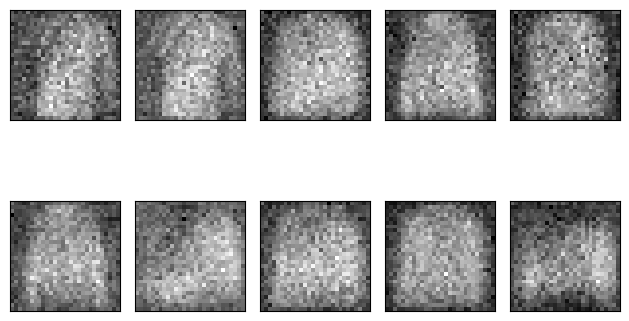

Currently on Epoch 2
	Currently on batch number 50 of 600
	Currently on batch number 100 of 600
	Currently on batch number 150 of 600
	Currently on batch number 200 of 600
	Currently on batch number 250 of 600
	Currently on batch number 300 of 600
	Currently on batch number 350 of 600
	Currently on batch number 400 of 600
	Currently on batch number 450 of 600
	Currently on batch number 500 of 600
	Currently on batch number 550 of 600
	Currently on batch number 600 of 600
  D Loss (Real): 0.2948 | D Acc (Real): 0.8100
  D Loss (Fake): 0.2948 | D Acc (Fake): 0.9400
  G Loss: 4.0779
Currently on Epoch 3
	Currently on batch number 50 of 600
	Currently on batch number 100 of 600
	Currently on batch number 150 of 600
	Currently on batch number 200 of 600
	Currently on batch number 250 of 600
	Currently on batch number 300 of 600
	Currently on batch number 350 of 600
	Currently on batch number 400 of 600
	Currently on batch number 450 of 600
	Currently on batch number 500 of 600
	Currently on

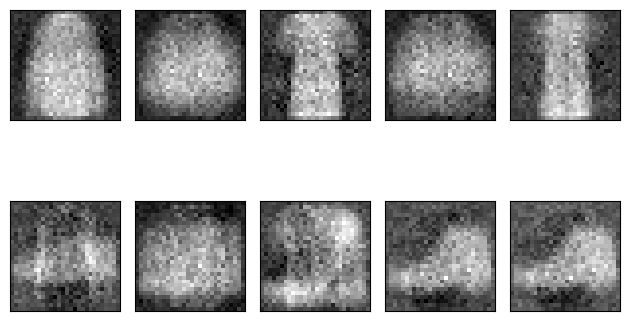

Currently on Epoch 12
	Currently on batch number 50 of 600
	Currently on batch number 100 of 600
	Currently on batch number 150 of 600
	Currently on batch number 200 of 600
	Currently on batch number 250 of 600
	Currently on batch number 300 of 600
	Currently on batch number 350 of 600
	Currently on batch number 400 of 600
	Currently on batch number 450 of 600
	Currently on batch number 500 of 600
	Currently on batch number 550 of 600
	Currently on batch number 600 of 600
  D Loss (Real): 0.4224 | D Acc (Real): 0.7800
  D Loss (Fake): 0.4224 | D Acc (Fake): 0.8800
  G Loss: 2.3252
Currently on Epoch 13
	Currently on batch number 50 of 600
	Currently on batch number 100 of 600
	Currently on batch number 150 of 600
	Currently on batch number 200 of 600
	Currently on batch number 250 of 600
	Currently on batch number 300 of 600
	Currently on batch number 350 of 600
	Currently on batch number 400 of 600
	Currently on batch number 450 of 600
	Currently on batch number 500 of 600
	Currently 

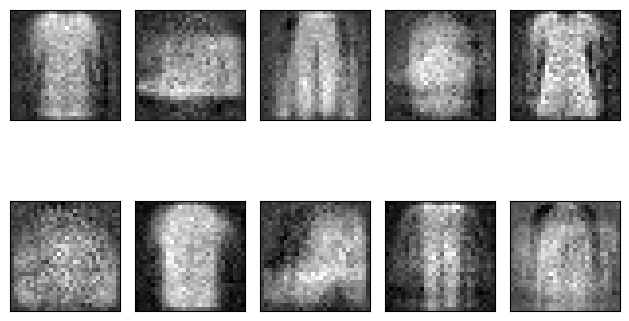

Currently on Epoch 22
	Currently on batch number 50 of 600
	Currently on batch number 100 of 600
	Currently on batch number 150 of 600
	Currently on batch number 200 of 600
	Currently on batch number 250 of 600
	Currently on batch number 300 of 600
	Currently on batch number 350 of 600
	Currently on batch number 400 of 600
	Currently on batch number 450 of 600
	Currently on batch number 500 of 600
	Currently on batch number 550 of 600
	Currently on batch number 600 of 600
  D Loss (Real): 0.4668 | D Acc (Real): 0.7600
  D Loss (Fake): 0.4668 | D Acc (Fake): 0.8000
  G Loss: 1.9181
Currently on Epoch 23
	Currently on batch number 50 of 600
	Currently on batch number 100 of 600
	Currently on batch number 150 of 600
	Currently on batch number 200 of 600
	Currently on batch number 250 of 600
	Currently on batch number 300 of 600
	Currently on batch number 350 of 600
	Currently on batch number 400 of 600
	Currently on batch number 450 of 600
	Currently on batch number 500 of 600
	Currently 

In [ ]:
# ── Plot learning curves: D-Loss and G-Loss across runs ─────────────────────
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = mlflow.get_experiment_by_name("Assignment3_Youhenna")
runs = client.search_runs(experiment_ids=[experiment.experiment_id])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for run in runs:
    name = run.info.run_name or run.info.run_id[:8]
    rid = run.info.run_id

    # D-Loss curve
    d_loss_hist = client.get_metric_history(rid, "d_loss")
    steps = [m.step for m in d_loss_hist]
    vals  = [m.value for m in d_loss_hist]
    axes[0].plot(steps, vals, label=name)

    # G-Loss curve
    g_loss_hist = client.get_metric_history(rid, "g_loss")
    steps_g = [m.step for m in g_loss_hist]
    vals_g  = [m.value for m in g_loss_hist]
    axes[1].plot(steps_g, vals_g, label=name)

    # D-Accuracy curve
    d_acc_hist = client.get_metric_history(rid, "d_accuracy")
    steps_a = [m.step for m in d_acc_hist]
    vals_a  = [m.value for m in d_acc_hist]
    axes[2].plot(steps_a, vals_a, label=name)

axes[0].set_title("Discriminator Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("D Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Generator Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("G Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_title("Discriminator Accuracy per Epoch")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("D Accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves_comparison.png", dpi=150)
plt.show()
print("Saved comparison plot -> learning_curves_comparison.png")

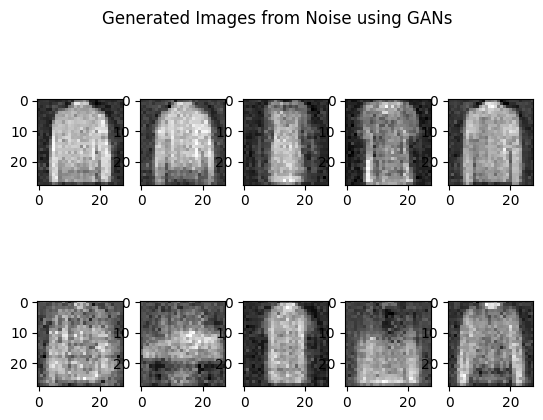

In [ ]:
## Analysis — Identifying the Best Model

**How to evaluate GAN runs:**
- For GANs, the ideal outcome is an **equilibrium** between the generator and discriminator, where:
  - **D-accuracy ≈ 0.5** (discriminator cannot distinguish real from fake)
  - **D-loss** and **G-loss** stabilise (no divergence or mode collapse)
- A run with **very high D-accuracy** means the discriminator dominates → generator is failing.
- A run with **very low D-accuracy** may indicate mode collapse.

**What to screenshot in the MLflow UI (http://localhost:5000):**
1. **Table View** — All 5 runs sorted by `final_d_accuracy`
2. **Comparison View** — Overlay the loss/accuracy curves of 3+ runs
3. **Artifact Gallery** — Click any run → Artifacts tab → `generator_model/` folder with `MLmodel`, `conda.yaml`, etc.

**Winner identification:** The best run is the one whose D-accuracy is closest to 0.5 with stable, non-diverging loss curves — that indicates the generator learned to produce realistic images while the discriminator remains challenged.